# Metadata exploration
Currently based on the entries from dbCAN-PUL

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# TO GET ETE4 TO WORK: python -c "from ete4 import NCBITaxa; NCBITaxa().update_taxonomy_database()"
from ete4 import NCBITaxa
ncbi = NCBITaxa()   

In [58]:
metadata = pd.read_excel("../PUL_data/dbCAN-PUL_Feb-2025.xlsx")
metadata.drop(columns=["PMID", "gene_locus_tags_or_modular", "old_other_gene_locus_tags_or_modules", "cazy_diamond_eval", "dbcan_hmmer_eval", "hotpep_hits", "tp_eval"], inplace=True)

In [89]:
def get_length(pos_range):
    if ',' in pos_range:
        pos_range = pos_range.split(',')[0]
    pos_range = pos_range.split('-')
    length = np.abs(float(pos_range[1]) - float(pos_range[0]))
    return length

def get_phylum(id):
    lineage = ncbi.get_lineage(id)
    ranks = ncbi.get_rank(lineage)
    names = ncbi.get_taxid_translator(lineage)

    for tid in lineage:
        if ranks.get(tid) in ("phylum", "clade"):
            return names.get(tid)
    return "Unknown"

metadata["PUL_length"] = metadata["nucleotide_position_range"].apply(get_length)
metadata['phylum'] = metadata["ncbi_species_tax_id"].apply(get_phylum)
metadata["proportion_cazymes"] = metadata["num_cazymes"].divide(metadata["num_genes"])

metadata.head()

,ID,verification_final,genomic_accession_number,nucleotide_position_range,substrate_final,organism_name,ncbi_species_tax_id,degradation_biosynthesis,num_cgcs,cazymes_predicted_dbCAN2,num_cazymes,num_genes,cazymes_predicted_dbcan,PUL_length,phylum,proportion_cazymes
0,PUL0001,"RNA-Seq,substrate binding assay,enzyme activit...",NZ_GG692714.1,156723-175880,beta-mannan,Roseburia intestinalis,166486,degradation,1,yes,9,15,"CE17|CBM35inCE17,CE2,GH1,GH113,GH130_1,GH130_2...",19157.0,Bacillota,0.6
1,PUL0002,"enzyme activity assay,Northern Blot",D83026.1,10377-12234,beta-glucan,Bacillus subtilis,1423,degradation,0,yes,1,2,GH16_21,1857.0,Bacillota,0.5
2,PUL0003,RT-PCR,NC_000964,1942714-1945654,xylan,Bacillus subtilis,1423,degradation,0,yes,2,2,"GH30_8,GH43_16|CBM6",2940.0,Bacillota,1.0
3,PUL0004,"enzyme activity assay,substrate binding assay",KM624528.1,1-3311,beta-glucan,uncultured bacterium,77133,degradation,1,yes,1,2,GH1,3310.0,Unknown,0.5
4,PUL0005,"enzyme activity assay,crystallization",NC_003212,1844298-1849726,beta-glucan,Listeria innocua,1642,degradation,0,yes,2,2,"GH3,GH94",5428.0,Bacillota,1.0


0 PULs with less than 2 genes


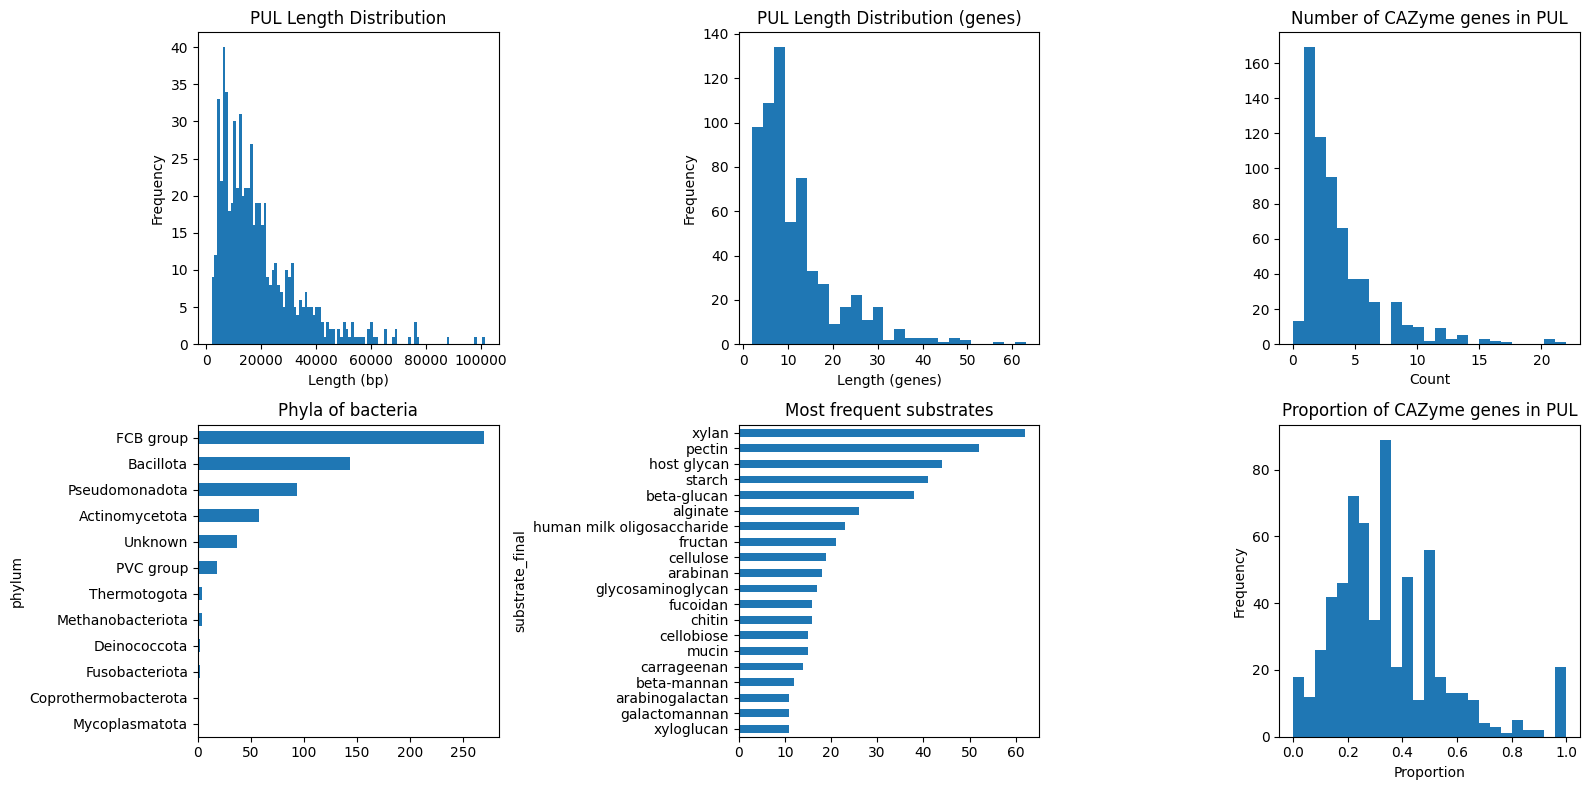

In [91]:
def plot_metadata(metadata):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    # plot PUL length distribution
    metadata["PUL_length"].plot.hist(title="PUL Length Distribution", bins=100, xlabel="Length (bp)", ax=axes[0])
    # plot length in genes
    metadata["num_genes"].plot.hist(title="PUL Length Distribution (genes)", bins=25, xlabel="Length (genes)", ax=axes[1])
    print(metadata['num_genes'][metadata['num_genes'] < 2].shape[0], "PULs with less than 2 genes")

    # plot count of CAZymes in PUL
    metadata['num_cazymes'].plot.hist(bins=25, ax=axes[2], title="Number of CAZyme genes in PUL", ylabel="", xlabel="Count")

    # plot taxonomic info
    metadata['phylum'].apply(lambda s: s.strip()).value_counts().sort_values().plot.barh(ax=axes[3], title="Phyla of bacteria")

    # plot substrate distribution
    metadata["substrate_final"].value_counts()[:20].sort_values().plot.barh(title="Most frequent substrates", ax=axes[4])
    # plot type of PUL
    # metadata['degradation_biosynthesis'].apply(lambda s: s.strip()).value_counts().plot.pie(ax=axes[5], title="PUL metabolic type", autopct="%1.1f%%")
        # plot proportion of cazymes in PUL
    metadata['proportion_cazymes'].plot.hist(bins=25, ax=axes[5], title="Proportion of CAZyme genes in PUL", xlabel="Proportion")

    plt.tight_layout()
    plt.show()

plot_metadata(metadata)

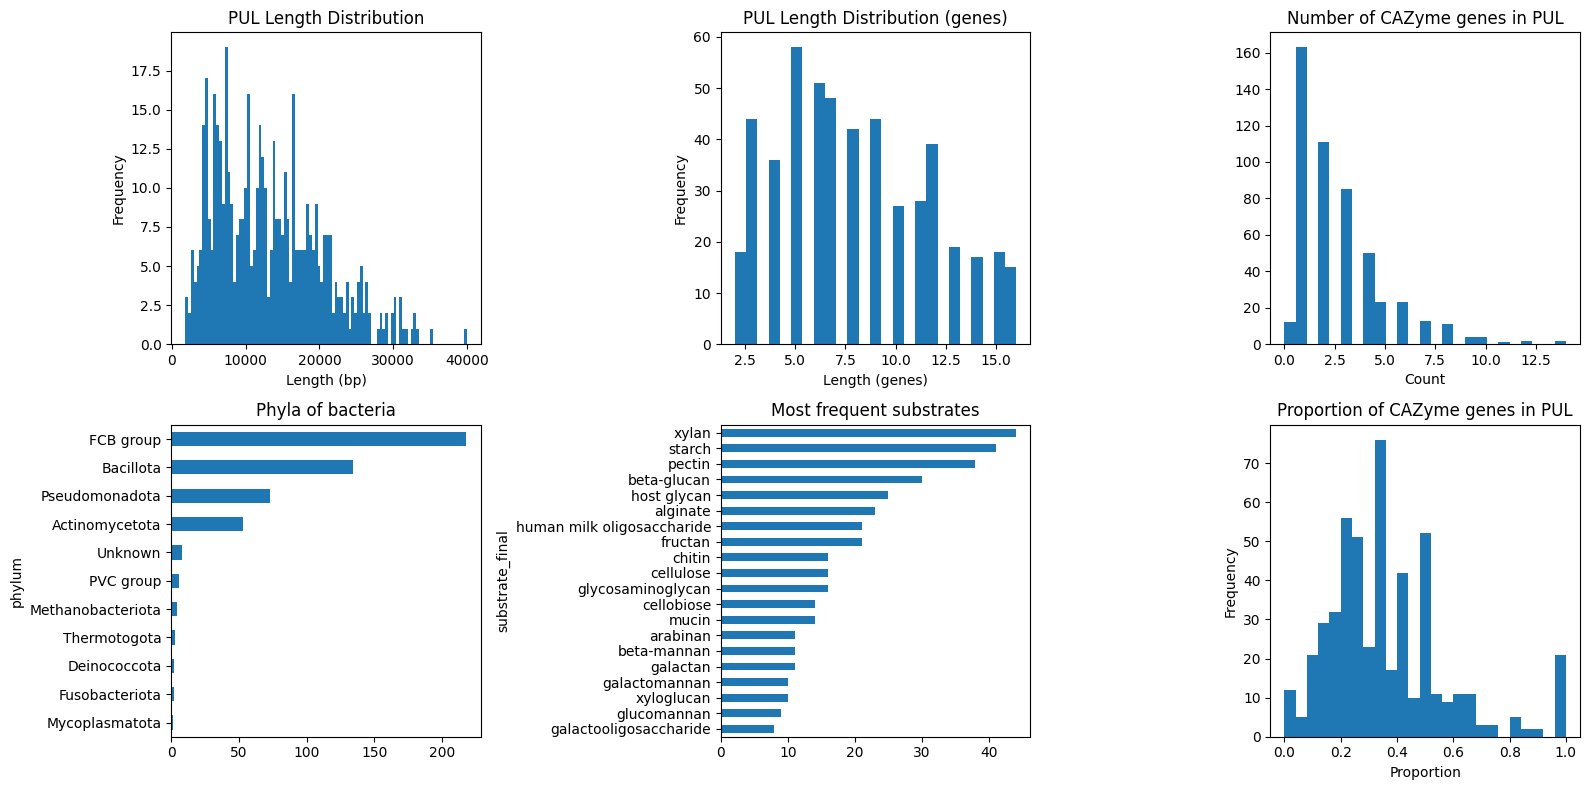

In [43]:
# filter to only 16 genes
metadata_16 = metadata[metadata["num_genes"] <= 16]
plot_metadata(metadata_16)

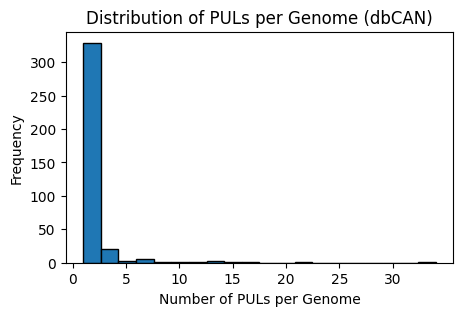

count
1     291
2      38
3      15
4       6
6       5
5       3
13      2
7       1
9       1
10      1
Name: count, dtype: int64
Total number of PULs: 631


In [94]:
# get cleaned cluster table with sequence_id, cluster_id, start, end
cluster_table = pd.read_csv('../PUL_data/preprocessed/genome.cluster.cleaned.tsv', sep='\t')
puls_per_genome = cluster_table.groupby('sequence_id').size().reset_index(name='count')

figure, ax = plt.subplots(figsize=(5, 3))
ax.hist(puls_per_genome['count'], bins=20, edgecolor='black', label='PULs per Genome for')
ax.set_xlabel('Number of PULs per Genome')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of PULs per Genome (dbCAN)')
# set proper x-ticks
ax.set_xticks(range(0, puls_per_genome['count'].max() + 1, 5))
plt.show()

print(puls_per_genome.sort_values(by='count', ascending=True)['count'].value_counts().head(10))
print(f"Total number of PULs: {puls_per_genome['count'].sum()}")

Total number of PULs: 358


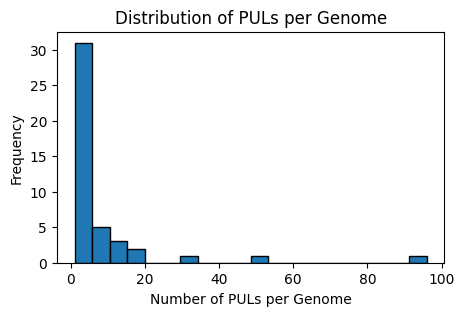

        sequence_id  len
10        NC_004663   96
3          FP476056   51
12        NC_009441   34
40  NZ_AAXF02000054   16
37  NZ_AAXF02000051   16
14        NC_015846   15
35  NZ_AAXF02000049   14
39  NZ_AAXF02000053   11
36  NZ_AAXF02000050   10
13        NC_013132   10


In [98]:
puldb_data_literature = pd.read_csv('../PUL_data/puldb_literature_PULs.tsv', sep='\t')
puls_per_genome = puldb_data_literature.groupby('sequence_id').size().reset_index(name='len')
print(f"Total number of PULs: {puls_per_genome['len'].sum()}")

figure, ax = plt.subplots(figsize=(5, 3))
ax.hist(puls_per_genome['len'], bins=20, edgecolor='black', label='PULs per Genome')
ax.set_xlabel('Number of PULs per Genome')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of PULs per Genome')
# set proper x-ticks
plt.show()

print(puls_per_genome.sort_values(by='len', ascending=False)[:10])

### Genome length distributions
length files obtained by 

`$ cat src/PUL_data/dbCAN-PUL_genomes_unique.gb | grep "LOCUS  " > src/PUL_data/dbcan_lengths.txt`

`$ cat src/PUL_data/puldb_literature_genomes.gb | grep "LOCUS  " > src/PUL_data/puldb_literature_lengths.txt`

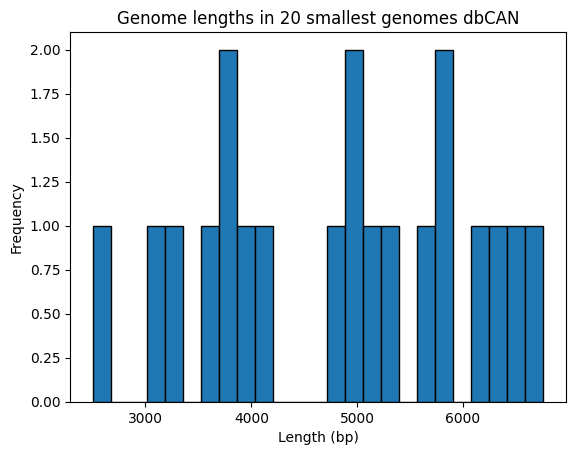

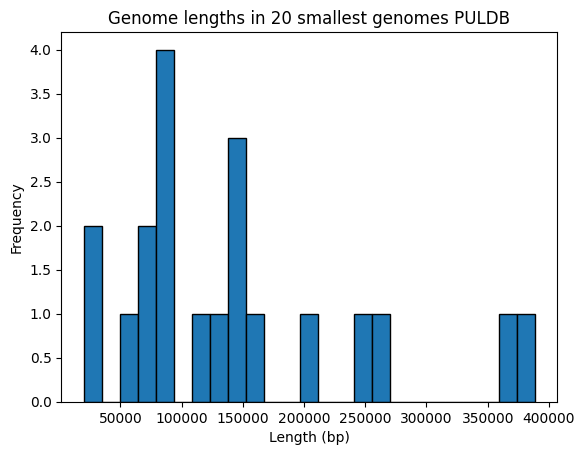

In [55]:
# parse length files
def parse_length_file(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    data = [[entry.strip('\n') for entry in line.split(' ') if len(entry) > 0][1:3] for line in lines]
    data = pd.DataFrame(data, columns=['sequence_id','length'], dtype=(str, float))
    return data

def plot_length_distribution(data, db_name):
    lengths = data['length'].astype(float)
    lengths.sort_values(inplace=True, ascending=True)
    bottom_20 = lengths[:20]
    bottom_20.plot.hist(bins=25, edgecolor='black', title=f"Genome lengths in 20 smallest genomes {db_name}", xlabel="Length (bp)")
    plt.show()

dbcan_length_df = parse_length_file('../PUL_data/dbCAN_lengths.txt')
puldb_length_df = parse_length_file('../PUL_data/puldb_literature_lengths.txt')

plot_length_distribution(dbcan_length_df, "dbCAN")
plot_length_distribution(puldb_length_df, "PULDB")


229/362 genomes have less than 10% of their genome in PULs
    sequence_id  pul_length   length  percentage_in_puls
9      AB011415       26942  14852.0          181.403178
170    LR131282       32539  31485.0          103.347626
190    MH687413       27137  27138.0           99.996315
158    KU644713       16597  16598.0           99.993975
121    HF548278       41172  41175.0           99.992714


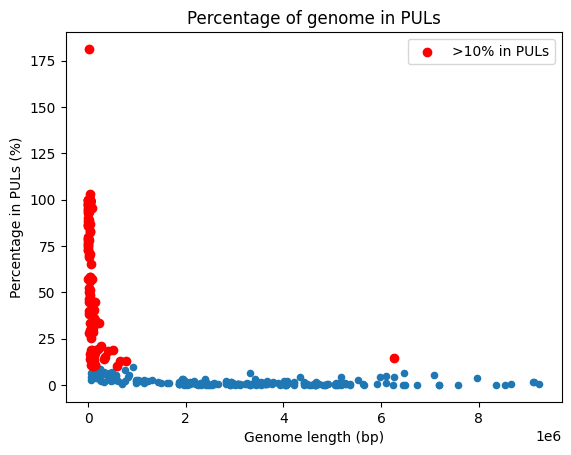

18/44 genomes have less than 10% of their genome in PULs
        sequence_id  pul_length    length  percentage_in_puls
37  NZ_AAXF02000051      383070  507553.0           75.473891
35  NZ_AAXF02000049      322756  428982.0           75.237656
17  NZ_AAXF02000026       20537   29967.0           68.532052
19  NZ_AAXF02000030       42751   70358.0           60.762102
18  NZ_AAXF02000029       35825   59901.0           59.807015


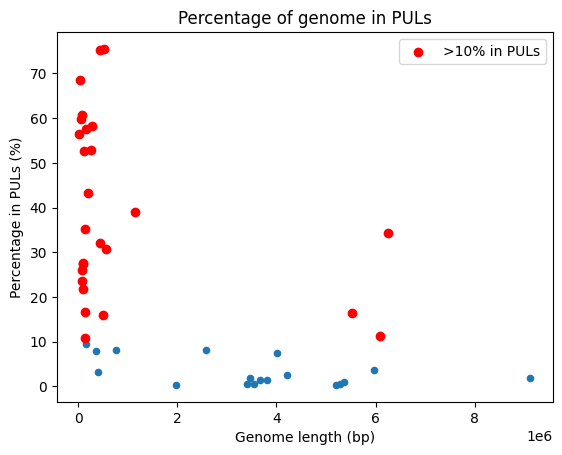

In [99]:
# plot percentage of bp in PULs for each genome
def get_percentage_bp_in_puls(cluster_table, length_df, cutoff):
    # get total length of PULs per genome
    pul_lengths = cluster_table.groupby('sequence_id').apply(lambda df: (df['end'] - df['start']).sum(), include_groups=False).reset_index(name='pul_length')
    # merge with length_df to get total genome length
    merged = pd.merge(pul_lengths, length_df, on='sequence_id')
    merged['length'] = merged['length'].astype(float)
    merged['percentage_in_puls'] = merged['pul_length'] / merged['length'] * 100
    print(f'{(merged["percentage_in_puls"] < cutoff).sum()}/{len(merged)} genomes have less than {cutoff}% of their genome in PULs')
    print(merged.sort_values(by='percentage_in_puls', ascending=False).head())
    return merged

def plot_percentage_bp_in_puls(cluster_table, length_df, cutoff=10):
    merged = get_percentage_bp_in_puls(cluster_table, length_df, cutoff=cutoff)
    merged[['percentage_in_puls', 'length']].plot.scatter(x="length", y="percentage_in_puls", title="Percentage of genome in PULs", xlabel="Genome length (bp)", ylabel="Percentage in PULs (%)")
    # color all above 20% in red
    plt.scatter(merged[merged['percentage_in_puls'] > cutoff]['length'], merged[merged['percentage_in_puls'] > cutoff]['percentage_in_puls'], color='red', label=f'>{cutoff}% in PULs')
    plt.legend()
    plt.show()

dbCAN_cluster_table = pd.read_csv('../PUL_data/preprocessed/genome.cluster.cleaned.tsv', sep='\t')
plot_percentage_bp_in_puls(dbCAN_cluster_table, dbcan_length_df)

PULDB_cluster_table = pd.read_csv('../PUL_data/puldb_literature_PULs.tsv', sep='\t')
plot_percentage_bp_in_puls(PULDB_cluster_table, puldb_length_df)